##CS7DS2 - Optimisation Algorithms for Data Analysis - Week 6 Assignment

Name : Swetha Sekar

Student ID : 25336453

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

##Question - 1

In [ ]:
#setup
np.random.seed(42)
m1 = 1000
X1 = np.random.randn(m1, 2)
theta_star = np.array([3.0, 4.0])
eps1 = np.random.randn(m1)
y1 = X1 @ theta_star + eps1
theta0 = np.array([1.0, 1.0])

In [6]:
def compute_loss_q1(theta, X, y):
    r = X @ theta - y
    return 0.5 * np.mean(r**2)

def compute_grad_q1(theta, Xb, yb):
    r = Xb @ theta - yb
    return Xb.T @ r / len(yb)

# contour grid
t1_vec = np.linspace(0.5, 4.5, 200)
t2_vec = np.linspace(1.5, 5.5, 200)
T1, T2 = np.meshgrid(t1_vec, t2_vec)
Z1 = np.vectorize(lambda a,b: compute_loss_q1(np.array([a,b]), X1, y1))(T1, T2)

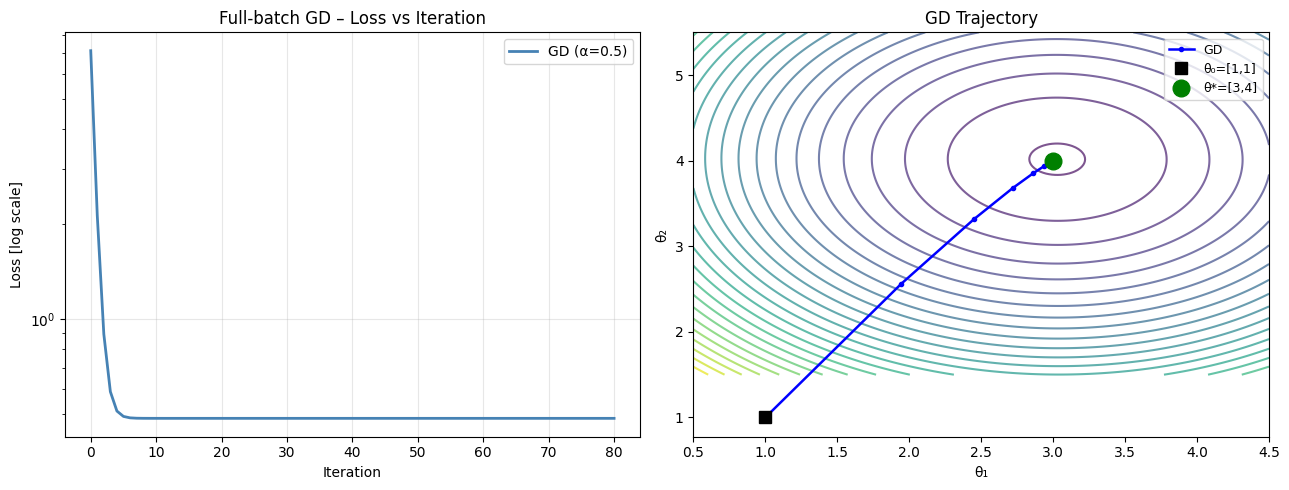

In [14]:
# Q1 - a
def compute_full_gd_q1a(theta0, X, y, alpha, itrs):
    theta = theta0.copy()
    losses = [compute_loss_q1(theta, X, y)]
    trjec = [theta.copy()]
    for _ in range(itrs):
        g_q1 = compute_grad_q1(theta, X, y)
        theta = theta - alpha * g_q1
        losses.append(compute_loss_q1(theta, X, y))
        trjec.append(theta.copy())
    return np.array(losses), np.array(trjec)

losses_q1a, trjec_q1a = compute_full_gd_q1a(theta0, X1, y1, alpha=0.5, itrs=80)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(losses_q1a, color='steelblue', linewidth=2, label='GD (α=0.5)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss [log scale]')
axes[0].set_title('Full-batch GD – Loss vs Iteration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].contour(T1, T2, Z1, levels=30, cmap='viridis', alpha=0.7)
axes[1].plot(trjec_q1a[:,0], trjec_q1a[:,1], 'b-o', ms=3, lw=1.8, label='GD')
axes[1].plot(*theta0, 'ks', ms=8,  label='θ₀=[1,1]')
axes[1].plot(*theta_star, 'go', ms=12, label='θ*=[3,4]')
axes[1].set_xlabel('θ₁')
axes[1].set_ylabel('θ₂')
axes[1].set_title('GD Trajectory')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('q1a.png', dpi=150, bbox_inches='tight')
plt.show()

The plot on the left shows the loss on a log scale, in which the straight downward line confirms the exponential decay at a consistent geometric rate. The plot on the right explores the parameter trajectory by overlaying them on the loss counters, showing how directly the iterations move towards $\theta^*$

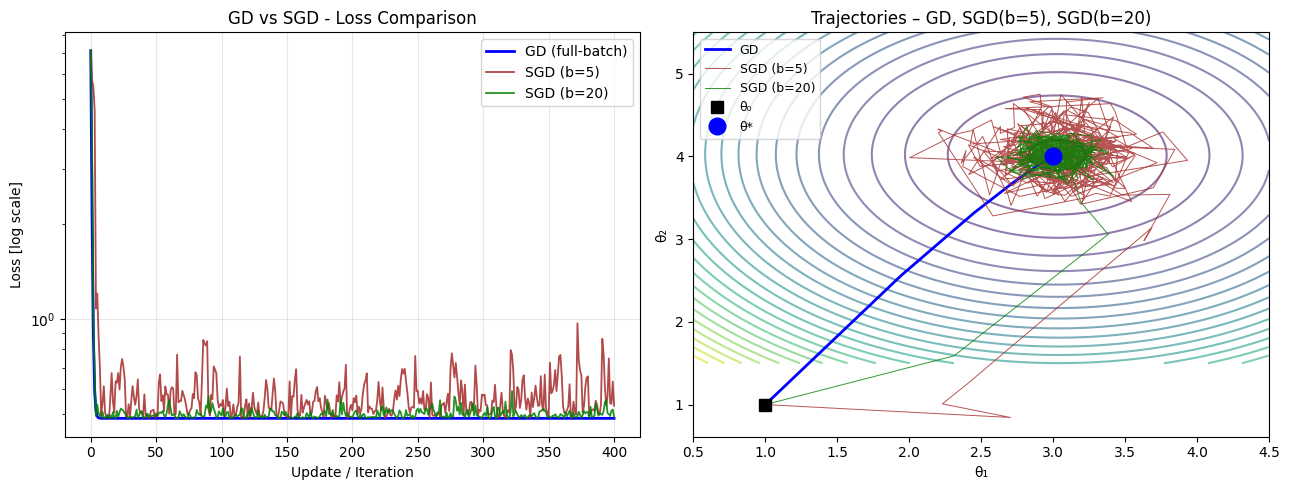

In [24]:
#Q1 - b
def compute_mbsgd_q1b(theta0, X, y, alpha, n_updts, batch_size, seed=42):
    np.random.seed(seed)
    theta = theta0.copy()
    n = len(y)
    losses = [compute_loss_q1(theta, X, y)]
    trjec = [theta.copy()]
    count = 0
    while count < n_updts:
        idx = np.random.permutation(n)
        Xs, ys = X[idx], y[idx]
        for i in range(0, n, batch_size):
            if count >= n_updts:
                break
            Xb, yb = Xs[i:i+batch_size], ys[i:i+batch_size]
            g      = compute_grad_q1(theta, Xb, yb)
            theta  = theta - alpha * g
            losses.append(compute_loss_q1(theta, X, y))
            trjec.append(theta.copy())
            count += 1
    return np.array(losses), np.array(trjec)

losses_q1a, trjec_q1a = compute_full_gd_q1a(theta0, X1, y1, alpha=0.5, itrs=400)
losses_q1b_5,  trjec_q1b_5  = compute_mbsgd_q1b(theta0, X1, y1, 0.5, 400, batch_size=5)
losses_q1b_20, trjec_q1b_20 = compute_mbsgd_q1b(theta0, X1, y1, 0.5, 400, batch_size=20)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(losses_q1a, lw=2.0, color='blue',  label='GD (full-batch)')
axes[0].semilogy(losses_q1b_5, lw=1.3, color='brown', label='SGD (b=5)',  alpha=0.85)
axes[0].semilogy(losses_q1b_20, lw=1.3, color='green',      label='SGD (b=20)', alpha=0.85)
axes[0].set_xlabel('Update / Iteration')
axes[0].set_ylabel('Loss [log scale]')
axes[0].set_title('GD vs SGD - Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].contour(T1, T2, Z1, levels=30, cmap='viridis', alpha=0.6)
axes[1].plot(trjec_q1a[:,0], trjec_q1a[:,1], 'b-', lw=2.0, label='GD')
axes[1].plot(trjec_q1b_5[:,0],  trjec_q1b_5[:,1], '-', lw=0.7, color='brown', alpha=0.8, label='SGD (b=5)')
axes[1].plot(trjec_q1b_20[:,0], trjec_q1b_20[:,1], '-', lw=0.7, color='green', alpha=0.8, label='SGD (b=20)')
axes[1].plot(*theta0, 'ks', ms=8,  label='θ₀')
axes[1].plot(*theta_star, 'bo', ms=12, label='θ*')
axes[1].set_xlabel('θ₁')
axes[1].set_ylabel('θ₂')
axes[1].set_title('Trajectories – GD, SGD(b=5), SGD(b=20)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('q1b.png', dpi=150, bbox_inches='tight')
plt.show()

In this graph, th e x-axis denotes the parameter updates rather than individual epochs in order to show GD and SGD on an equal footing. Also, the contour plot shows all three trajectories simultaneously, where the effect of gradien tnoise is visualised by the SGD paths relative to GD.

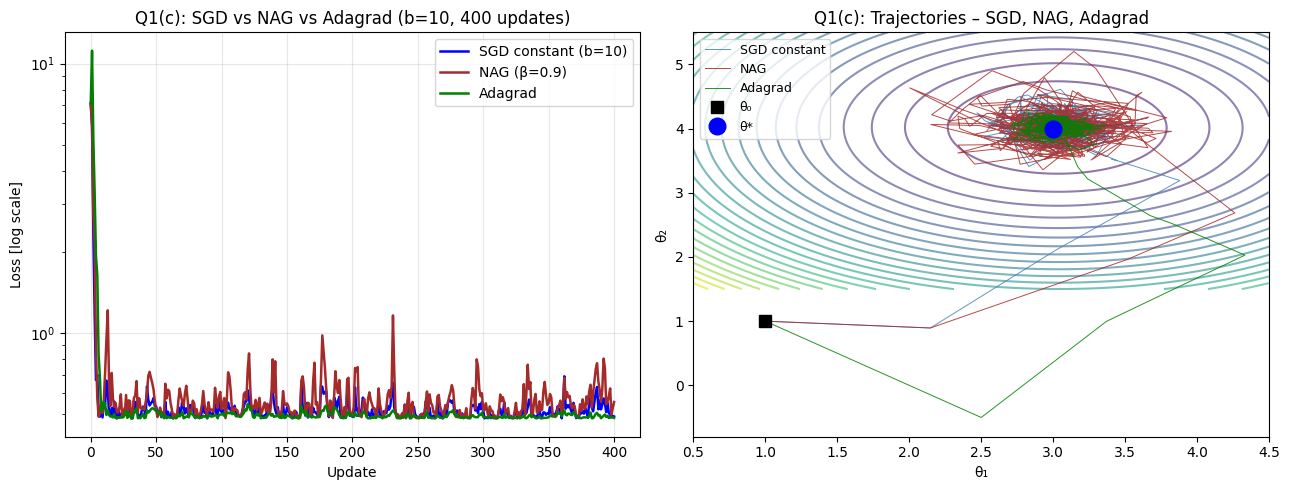

In [23]:
#Q1 - c
def compute_nag_sgd_q1c(theta0, X, y, alpha, beta, n_upds, batch_size, seed=42):
    np.random.seed(seed)
    theta = theta0.copy()
    z = np.zeros_like(theta)
    n = len(y)
    losses = [compute_loss_q1(theta, X, y)]
    trjec = [theta.copy()]
    count = 0
    while count < n_upds:
        idx = np.random.permutation(n)
        Xs, ys = X[idx], y[idx]
        for i in range(0, n, batch_size):
            if count >= n_upds:
                break
            Xb, yb = Xs[i:i+batch_size], ys[i:i+batch_size]
            theta_look = theta + beta * z
            g_q1c = compute_grad_q1(theta_look, Xb, yb)
            z = beta * z - alpha * g_q1c
            theta = theta + z
            losses.append(compute_loss_q1(theta, X, y))
            trjec.append(theta.copy())
            count += 1
    return np.array(losses), np.array(trjec)


def compute_adagrad_sgd_q1c(theta0, X, y, alpha, n_upds, batch_size, eps=1e-8, seed=42):
    np.random.seed(seed)
    theta = theta0.copy()
    G = np.zeros_like(theta)
    n = len(y)
    losses = [compute_loss_q1(theta, X, y)]
    traj = [theta.copy()]
    count = 0
    while count < n_upds:
        idx = np.random.permutation(n)
        Xs, ys = X[idx], y[idx]
        for i in range(0, n, batch_size):
            if count >= n_upds:
                break
            Xb, yb = Xs[i:i+batch_size], ys[i:i+batch_size]
            g = compute_grad_q1(theta, Xb, yb)
            G += g**2
            theta  = theta - alpha * g / (np.sqrt(G) + eps)
            losses.append(compute_loss_q1(theta, X, y))
            traj.append(theta.copy())
            count += 1
    return np.array(losses), np.array(traj)

losses_sgd1_10, traj_sgd1_10 = compute_mbsgd_q1b(theta0, X1, y1, 0.5,  400, batch_size=10)
losses_nag1, traj_nag1  = compute_nag_sgd_q1c(theta0, X1, y1, alpha=0.5, beta=0.9, n_upds=400, batch_size=10)
losses_ada1, traj_ada1  = compute_adagrad_sgd_q1c(theta0, X1, y1, alpha=1.5, n_upds=400, batch_size=10)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(losses_sgd1_10, lw=1.8, color='blue',  label='SGD constant (b=10)')
axes[0].semilogy(losses_nag1, lw=1.8, color='brown', label='NAG (β=0.9)')
axes[0].semilogy(losses_ada1, lw=1.8, color='green', label='Adagrad')
axes[0].set_xlabel('Update')
axes[0].set_ylabel('Loss [log scale]')
axes[0].set_title('Q1(c): SGD vs NAG vs Adagrad (b=10, 400 updates)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].contour(T1, T2, Z1, levels=30, cmap='viridis', alpha=0.6)
axes[1].plot(traj_sgd1_10[:,0], traj_sgd1_10[:,1], '-', lw=0.7, color='steelblue',  alpha=0.85, label='SGD constant')
axes[1].plot(traj_nag1[:,0],  traj_nag1[:,1],  '-', lw=0.7, color='brown', alpha=0.85, label='NAG')
axes[1].plot(traj_ada1[:,0],  traj_ada1[:,1],  '-', lw=0.7, color='green',  alpha=0.85, label='Adagrad')
axes[1].plot(*theta0,  'ks', ms=8,  label='θ₀')
axes[1].plot(*theta_star, 'bo', ms=12, label='θ*')
axes[1].set_xlabel('θ₁')
axes[1].set_ylabel('θ₂')
axes[1].set_title('Q1(c): Trajectories – SGD, NAG, Adagrad')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('q1c.png', dpi=150, bbox_inches='tight')
plt.show()

The relative speed and stability of both the methods are observed from the loss curve. From the contour plot, we can see how close each trajectory follows the valley floor rather than bouncing sideways, thus revealing how both of them handle anisotropic curvature.

##Question - 2

In [25]:
#setup
np.random.seed(42)
m2 = 1000
u2 = np.random.uniform(-2, 2, m2)
x_star_q2 = np.array([1.0, 3.0])
eps2  = np.random.randn(m2) * 0.05
y2 = x_star_q2[1] * np.tanh(x_star_q2[0] * u2) + eps2
x0_q2 = np.array([1.0, 1.0])


In [28]:
def compute_yhat_q2(u, x):
    return x[1] * np.tanh(x[0] * u)

def compute_loss_q2(x, u, y):
    return 0.5 * np.mean((compute_yhat_q2(u, x) - y)**2)

def compute_grad_q2(x, u, y):
    r = compute_yhat_q2(u, x) - y
    th = np.tanh(x[0] * u)
    sc2 = 1.0 - th**2
    g1 = np.mean(r * x[1] * sc2 * u)
    g2 = np.mean(r * th)
    return np.array([g1, g2])

#contour grid
x1_vec = np.linspace(0.3, 1.7, 200)
x2_vec = np.linspace(0.5, 5.5, 200)
X1G, X2G = np.meshgrid(x1_vec, x2_vec)
Z2 = np.vectorize(lambda a,b: compute_loss_q2(np.array([a,b]), u2, y2))(X1G, X2G)

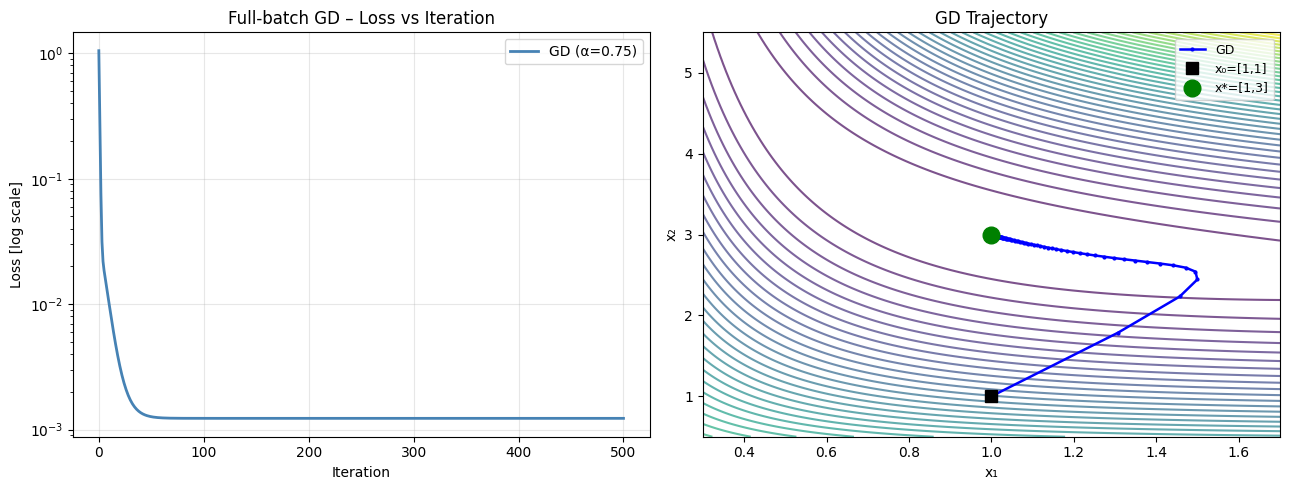

In [31]:
#Q2 - a
def compute_full_gd_q2a(x0, u, y, alpha, itrs):
    x      = x0.copy()
    losses = [compute_loss_q2(x, u, y)]
    trjec   = [x.copy()]
    for _ in range(itrs):
        g = compute_grad_q2(x, u, y)
        x = x - alpha * g
        losses.append(compute_loss_q2(x, u, y))
        trjec.append(x.copy())
    return np.array(losses), np.array(trjec)

losses_q2a, trjec_q2a = compute_full_gd_q2a(x0_q2, u2, y2, alpha=0.75, itrs=500)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(losses_q2a, color='steelblue', lw=2, label='GD (α=0.75)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss [log scale]')
axes[0].set_title('Full-batch GD – Loss vs Iteration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].contour(X1G, X2G, Z2, levels=40, cmap='viridis', alpha=0.7)
axes[1].plot(trjec_q2a[:,0], trjec_q2a[:,1], 'b-o', ms=2, lw=1.8, label='GD')
axes[1].plot(*x0_q2, 'ks', ms=8,  label='x₀=[1,1]')
axes[1].plot(*x_star_q2, 'go', ms=12, label='x*=[1,3]')
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')
axes[1].set_title('GD Trajectory')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('q2a.png', dpi=150, bbox_inches='tight')
plt.show()

The log-scale loss scale is smooth but it is not perfect, and the varying curvature of the tanh surface means the decay rate changes along the trajectory. But the contour plot reveals the key geometric challenge, a highly elongated valley along $x_2$, which the trajectory must navigate from $x_0 = [1,1]$ down to $x^* = [1,3]$.

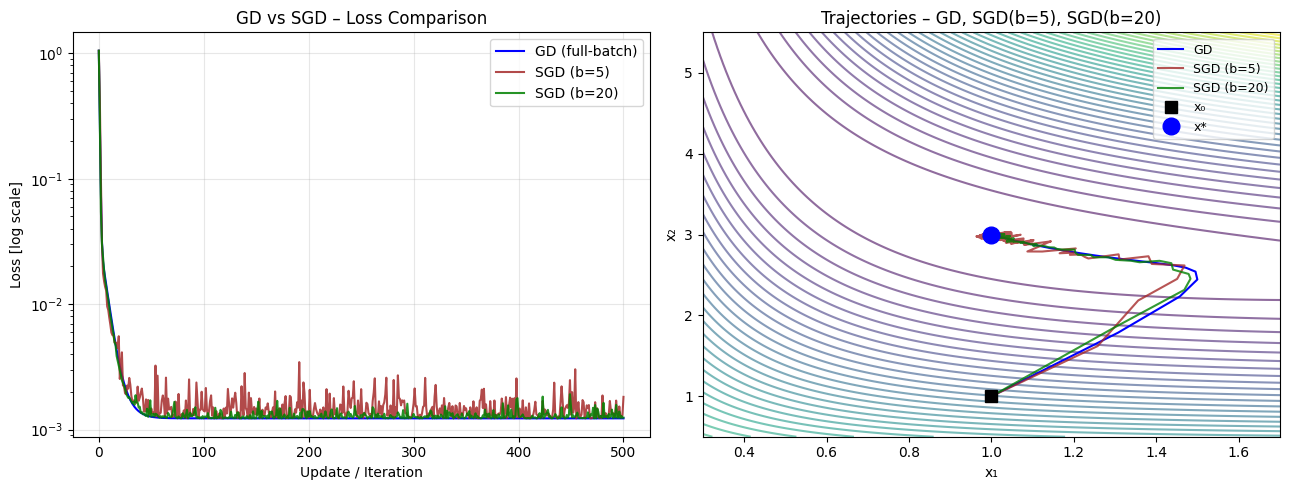

In [36]:
#Q2 - b
def compute_minibatch_sgd_q2b(x0, u, y, alpha, n_updts, batch_size, seed=42):
    np.random.seed(seed)
    x = x0.copy()
    n = len(y)
    losses = [compute_loss_q2(x, u, y)]
    trjec = [x.copy()]
    count = 0
    while count < n_updts:
        idx = np.random.permutation(n)
        us, ys = u[idx], y[idx]
        for i in range(0, n, batch_size):
            if count >= n_updts:
                break
            ub, yb = us[i:i+batch_size], ys[i:i+batch_size]
            g = compute_grad_q2(x, ub, yb)
            x = x - alpha * g
            losses.append(compute_loss_q2(x, u, y))
            trjec.append(x.copy())
            count += 1
    return np.array(losses), np.array(trjec)

losses_q2a, trjec_q2a = compute_full_gd_q2a(x0_q2, u2, y2, alpha=0.75, itrs=500)
losses_q2b_5,  trjec_q2b_5  = compute_minibatch_sgd_q2b(x0_q2, u2, y2, 0.75, 500, batch_size=5)
losses_q2b_20, trjec_q2b_20 = compute_minibatch_sgd_q2b(x0_q2, u2, y2, 0.75, 500, batch_size=20)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(losses_q2a,  color='steelblue',  label='GD (full-batch)')
axes[0].semilogy(losses_q2b_5,   color='brown', label='SGD (b=5)',  alpha=0.85)
axes[0].semilogy(losses_q2b_20,  lw=1.3, color='green',      label='SGD (b=20)', alpha=0.85)
axes[0].set_xlabel('Update / Iteration')
axes[0].set_ylabel('Loss [log scale]')
axes[0].set_title('GD vs SGD – Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].contour(X1G, X2G, Z2, levels=40, cmap='viridis', alpha=0.6)
axes[1].plot(trjec_q2a[:,0], trjec_q2a[:,1],  'b-', label='GD')
axes[1].plot(trjec_q2b_5[:,0], trjec_q2b_5[:,1], '-', color='brown', alpha=0.8, label='SGD (b=5)')
axes[1].plot(trjec_q2b_20[:,0], trjec_q2b_20[:,1], '-', color='green', alpha=0.8, label='SGD (b=20)')
axes[1].plot(*x0_q2, 'ks', ms=8,  label='x₀')
axes[1].plot(*x_star_q2, 'bo', ms=12, label='x*')
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')
axes[1].set_title('Trajectories – GD, SGD(b=5), SGD(b=20)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('q2b.png', dpi=150, bbox_inches='tight')
plt.show()

The x-axis is kept as parameter updates to put all the methods on equal footing. The contour plot shows a curved, narrow valley, which means SGD trajectories scatter not only around the optimum but also across the valley walls, which is obvious for small batch sizes.

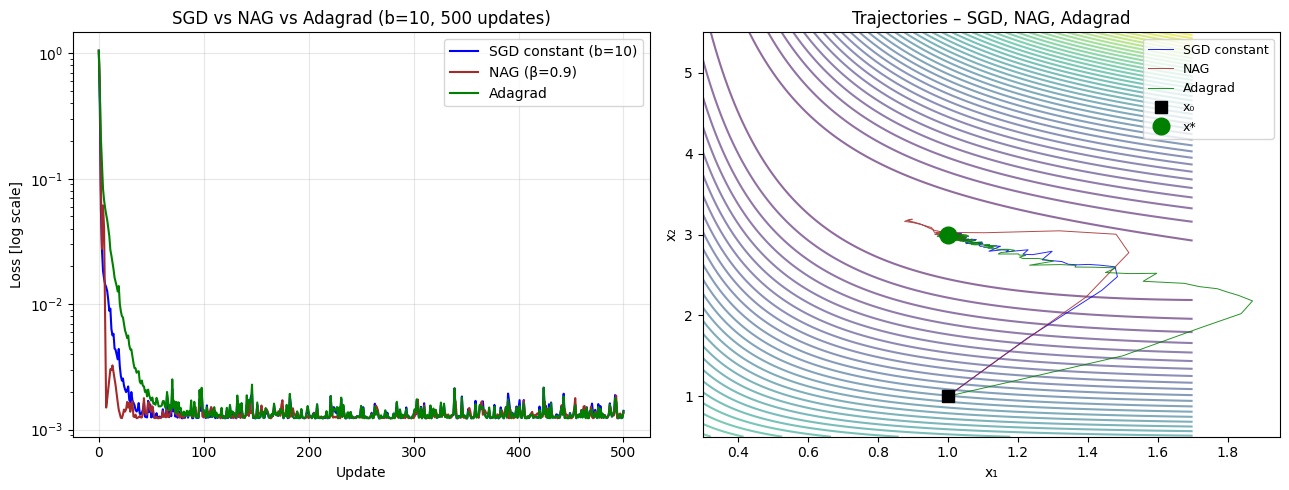

In [40]:
#Q2 - c
def compute_nag_sgd_q2(x0, u, y, alpha, beta, n_updts, batch_size, seed=42):
    np.random.seed(seed)
    x = x0.copy()
    z = np.zeros_like(x)
    n = len(y)
    losses = [compute_loss_q2(x, u, y)]
    trjec = [x.copy()]
    count = 0
    while count < n_updts:
        idx = np.random.permutation(n)
        us, ys = u[idx], y[idx]
        for i in range(0, n, batch_size):
            if count >= n_updts:
                break
            ub, yb = us[i:i+batch_size], ys[i:i+batch_size]
            x_look = x + beta * z
            g = compute_grad_q2(x_look, ub, yb)
            z = beta * z - alpha * g
            x = x + z
            losses.append(compute_loss_q2(x, u, y))
            trjec.append(x.copy())
            count += 1
    return np.array(losses), np.array(trjec)


def compute_adagrad_sgd_q2(x0, u, y, alpha, n_updts, batch_size, eps=1e-8, seed=42):
    np.random.seed(seed)
    x = x0.copy()
    G = np.zeros_like(x)
    n = len(y)
    losses = [compute_loss_q2(x, u, y)]
    trjec  = [x.copy()]
    count  = 0
    while count < n_updts:
        idx = np.random.permutation(n)
        us, ys = u[idx], y[idx]
        for i in range(0, n, batch_size):
            if count >= n_updts:
                break
            ub, yb = us[i:i+batch_size], ys[i:i+batch_size]
            g = compute_grad_q2(x, ub, yb)
            G += g**2
            x = x - alpha * g / (np.sqrt(G) + eps)
            losses.append(compute_loss_q2(x, u, y))
            trjec.append(x.copy())
            count += 1
    return np.array(losses), np.array(trjec)

losses_sgd2_10, traj_sgd2_10 = compute_minibatch_sgd_q2b(x0_q2, u2, y2, 0.75, 500, batch_size=10)
losses_nag_q2c, traj_nag_q2c = compute_nag_sgd_q2(x0_q2, u2, y2, alpha=0.5, beta=0.9, n_updts=500, batch_size=10)
losses_ada_q2c, traj_ada_q2c = compute_adagrad_sgd_q2(x0_q2, u2, y2, alpha=0.5, n_updts=500, batch_size=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(losses_sgd2_10, color='blue',  label='SGD constant (b=10)')
axes[0].semilogy(losses_nag_q2c, color='brown', label='NAG (β=0.9)')
axes[0].semilogy(losses_ada_q2c, color='green',      label='Adagrad')
axes[0].set_xlabel('Update')
axes[0].set_ylabel('Loss [log scale]')
axes[0].set_title('SGD vs NAG vs Adagrad (b=10, 500 updates)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].contour(X1G, X2G, Z2, levels=40, cmap='viridis', alpha=0.6)
axes[1].plot(traj_sgd2_10[:,0], traj_sgd2_10[:,1], '-', lw=0.7, color='blue',  alpha=0.85, label='SGD constant')
axes[1].plot(traj_nag_q2c[:,0], traj_nag_q2c[:,1], '-', lw=0.7, color='brown', alpha=0.85, label='NAG')
axes[1].plot(traj_ada_q2c[:,0], traj_ada_q2c[:,1], '-', lw=0.7, color='green', alpha=0.85, label='Adagrad')
axes[1].plot(*x0_q2, 'ks', ms=8,  label='x₀')
axes[1].plot(*x_star_q2, 'go', ms=12, label='x*')
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')
axes[1].set_title('Trajectories – SGD, NAG, Adagrad')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('q2c.png', dpi=150, bbox_inches='tight')
plt.show()

The loss curves demonstrates the speed advantage of NAG and Adagrad over plain SGD. The contour plot shows how each method navigates the elongated curved valley efficiently and how it bounces across the sideways.

##Question - 3

In [42]:
#setup
x0_q3 = np.array([-1.0, 1.0])
xstar_q3 = np.array([ 1.0, 1.0])

def get_rosenbrock(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def compute_rosenbrock_grad(x):
    g1 = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
    g2 =  200*(x[1] - x[0]**2)
    return np.array([g1, g2])

xr1 = np.linspace(-1.5, 1.5, 500)
xr2 = np.linspace(-0.5, 1.8, 500)
XR1, XR2 = np.meshgrid(xr1, xr2)
ZR = (1 - XR1)**2 + 100*(XR2 - XR1**2)**2

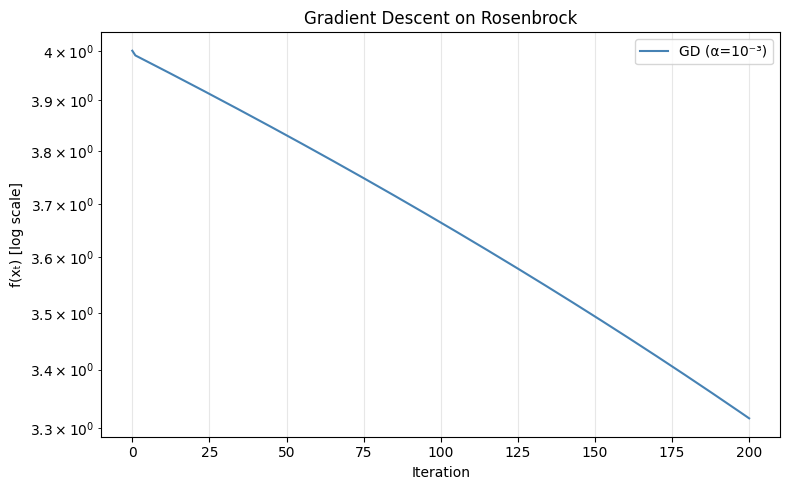

In [46]:
#Q3 - a
def compute_gd_rosenbrock(x0, alpha, n_iters):
    x = x0.copy()
    losses = [get_rosenbrock(x)]
    trjec = [x.copy()]
    for _ in range(n_iters):
        g = compute_rosenbrock_grad(x)
        x = x - alpha * g
        losses.append(get_rosenbrock(x))
        trjec.append(x.copy())
    return np.array(losses), np.array(trjec)

losses_q3a, trjec_q3a = compute_gd_rosenbrock(x0_q3, alpha=1e-3, n_iters=200)

fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(losses_q3a, color='steelblue', label='GD (α=10⁻³)')
ax.set_xlabel('Iteration')
ax.set_ylabel('f(xₜ) [log scale]')
ax.set_title('Gradient Descent on Rosenbrock')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('q3a.png', dpi=150, bbox_inches='tight')
plt.show()

Here, the log-scale curves denotes the overall gradient descent trend, which is quite slow and uneven, and it is the signature of a highly ill-conditioned problem like Rosenbrock.

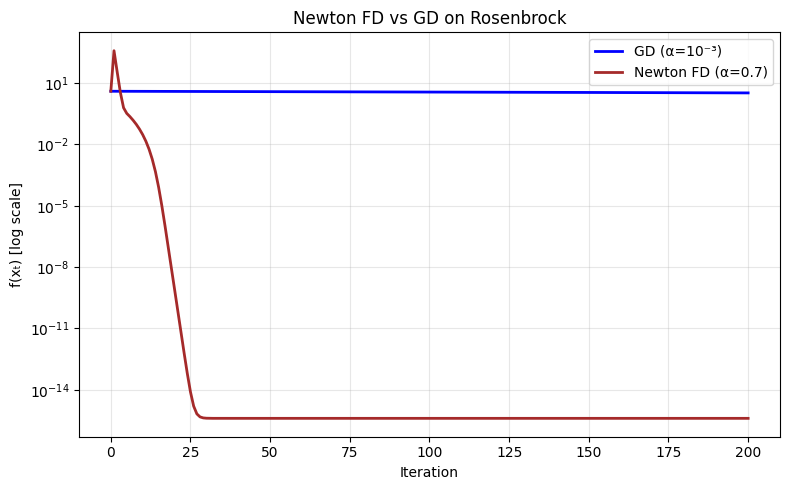

In [49]:
#Q3 - b
def compute_fd_grad(f, x, h=1e-5):
    n = len(x)
    g = np.zeros(n)
    for i in range(n):
        ei = np.zeros(n); ei[i] = 1.0
        g[i] = (f(x + h*ei) - f(x - h*ei)) / (2*h)
    return g

def compute_fd_hess(f, x, h=1e-4):
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei = np.zeros(n); ei[i] = 1.0
            ej = np.zeros(n); ej[j] = 1.0
            fpp = f(x + h*ei + h*ej)
            fpm = f(x + h*ei - h*ej)
            fmp = f(x - h*ei + h*ej)
            fmm = f(x - h*ei - h*ej)
            H[i, j] = (fpp - fpm - fmp + fmm) / (4*h**2)
    return H

def compute_newton_rb(x0, alpha=0.7, itrs=200, lam=1e-6):
    x = x0.copy()
    losses = [get_rosenbrock(x)]
    trjec = [x.copy()]
    for _ in range(itrs):
        g = compute_fd_grad(get_rosenbrock, x)
        H = compute_fd_hess(get_rosenbrock, x)
        H_reg = H + lam * np.eye(len(x))
        try:
            p = np.linalg.solve(H_reg, g)
        except np.linalg.LinAlgError:
            p = g
        x = x - alpha * p
        losses.append(get_rosenbrock(x))
        trjec.append(x.copy())
    return np.array(losses), np.array(trjec)

losses_newt_q3b, trjec_newt_q3b = compute_newton_rb(x0_q3, alpha=0.7, itrs=200)

fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(losses_q3a,   color='blue',  lw=2, label='GD (α=10⁻³)')
ax.semilogy(losses_newt_q3b, color='brown', lw=2, label='Newton FD (α=0.7)')
ax.set_xlabel('Iteration')
ax.set_ylabel('f(xₜ) [log scale]')
ax.set_title('Newton FD vs GD on Rosenbrock')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('q3b.png', dpi=150, bbox_inches='tight')
plt.show()

Plotting the GD and Newton on the same log scale illustrates the stark difference in the convergence gap. It is seen that Newton's curve drops sharply around the initial 30-50 iterations, while GD barely progresses.

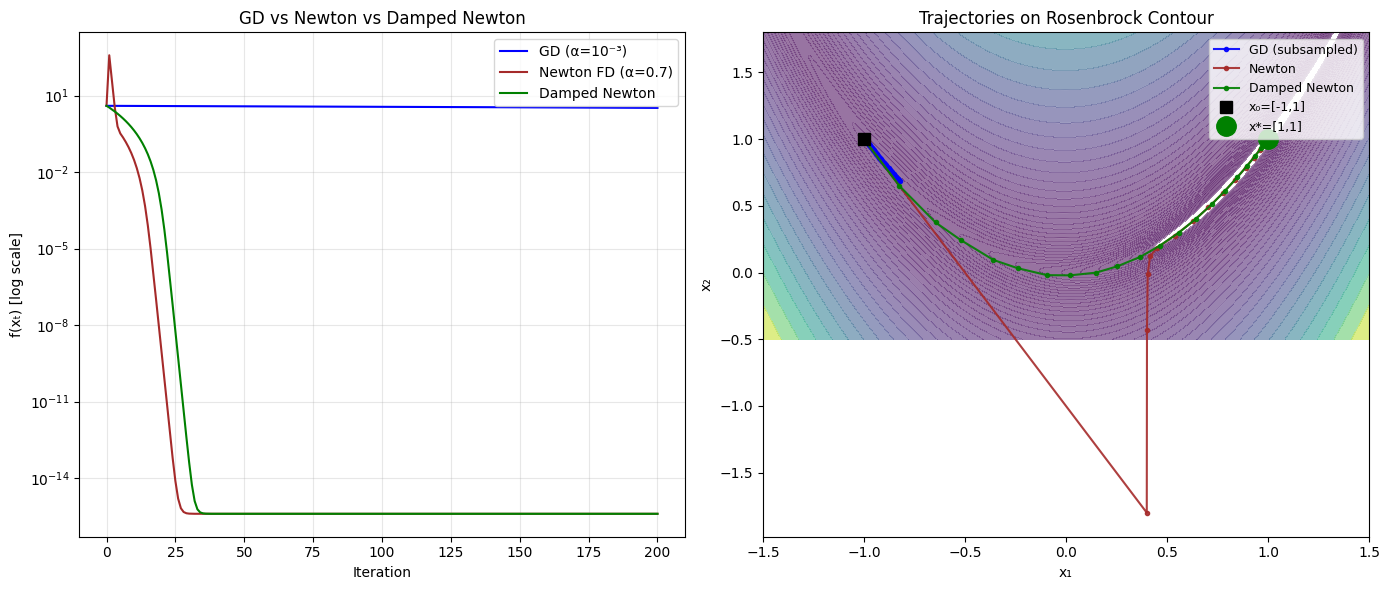

In [53]:
#Q3 - c
def compute_damped_newton_rb(x0, alpha0=0.7, rho=0.5, K=20, itrs=200, lam=1e-6):
    x = x0.copy()
    losses = [get_rosenbrock(x)]
    trjec = [x.copy()]
    for _ in range(itrs):
        ft = get_rosenbrock(x)
        g = compute_fd_grad(get_rosenbrock, x)
        H = compute_fd_hess(get_rosenbrock, x)
        H_reg = H + lam * np.eye(len(x))
        try:
            p = np.linalg.solve(H_reg, g)
        except np.linalg.LinAlgError:
            p = g

        alpha = alpha0
        accepted = False
        for _ in range(K):
            if get_rosenbrock(x - alpha * p) < ft:
                accepted = True
                break
            alpha *= rho

        x = (x - alpha * p) if accepted else (x - 1e-4 * g)
        losses.append(get_rosenbrock(x))
        trjec.append(x.copy())
    return np.array(losses), np.array(trjec)

losses_dn_q3c, traj_dn_q3c = compute_damped_newton_rb(x0_q3, alpha0=0.7, rho=0.5, K=20, itrs=200)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].semilogy(losses_q3a,  color='blue', label='GD (α=10⁻³)')
axes[0].semilogy(losses_newt_q3b, color='brown',  label='Newton FD (α=0.7)')
axes[0].semilogy(losses_dn_q3c,  color='green',  label='Damped Newton')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('f(xₜ) [log scale]')
axes[0].set_title('GD vs Newton vs Damped Newton')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

levels = np.logspace(-0.5, np.log10(ZR.max()), 40)
axes[1].contourf(XR1, XR2, ZR, levels=levels, cmap='viridis', alpha=0.55)
axes[1].contour( XR1, XR2, ZR, levels=levels, colors='white', linewidths=0.35, alpha=0.4)

step = max(1, len(trjec_q3a) // 60)
axes[1].plot(trjec_q3a[::step,0], trjec_q3a[::step,1], 'b-o', ms=3, label='GD (subsampled)', alpha=0.9)
axes[1].plot(trjec_newt_q3b[:,0], trjec_newt_q3b[:,1], '-o', color='brown', ms=3, label='Newton', alpha=0.9)
axes[1].plot(traj_dn_q3c[:,0], traj_dn_q3c[:,1],  '-o', color='green', ms=3, label='Damped Newton', alpha=0.9)
axes[1].plot(*x0_q3, 'ks', ms=9,  label='x₀=[-1,1]')
axes[1].plot(*xstar_q3, 'go', ms=14, label='x*=[1,1]')
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')
axes[1].set_title('Trajectories on Rosenbrock Contour')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('q3c.png', dpi=150, bbox_inches='tight')
plt.show()

The loss plot compares all the three methods, where the gap between GD and both the Newton methods is obvious. The right contour plot shows that the GD's path bouncing along the valley walls contrasts directly with the clean trajectories of Newton methods, towards $x^* = [1,1]$.  
